In [2]:
import pandas as pd

In [3]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np

df = pd.read_csv('UP_Final_dataset.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()


# Features and target
feature_cols = [
    'temp_weighted', 'month', 'holiday',
    'is_weekend', 'hour', 'minute',
    'y_lag_24h', 'y_lag_7d' , 'y_lag_1'
]

X = df[feature_cols]
y = df['hourly_demand_met_mw']

# Temporal split — train / val / test
X_train = X[df.index < '2025-07-01']
y_train = y[df.index < '2025-07-01']

X_val   = X[(df.index >= '2025-07-01') & (df.index < '2026-01-01')]
y_val   = y[(df.index >= '2025-07-01') & (df.index < '2026-01-01')]

X_test  = X[df.index >= '2026-01-01']
y_test  = y[df.index >= '2026-01-01']

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

# Train — early stopping on validation
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val)

params = {
    'objective':         'regression',
    'metric':            'rmse',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'verbose':           -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# Evaluate on validation
y_val_pred = model.predict(X_val)
val_mape   = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
print(f'\nVal MAPE:  {val_mape:.2f}%')

# Evaluate on test
y_pred = model.predict(X_test)
mae    = mean_absolute_error(y_test, y_pred)
rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'\nTest MAE:  {mae:.2f} MW')
print(f'Test RMSE: {rmse:.2f} MW')
print(f'Test MAPE: {mape:.2f}%')

Train: (51840, 9)
Val:   (17664, 9)
Test:  (8637, 9)
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 266.793
[200]	valid_0's rmse: 231.982
Early stopping, best iteration is:
[231]	valid_0's rmse: 230.46

Val MAPE:  0.93%

Test MAE:  212.89 MW
Test RMSE: 286.78 MW
Test MAPE: 1.31%


In [4]:
avg_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f'MAPE: {avg_mape:.2f}%')

MAPE: 1.31%


In [5]:
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred}, index=X_test.index)
results['mape'] = np.abs((results['actual'] - results['predicted']) / results['actual']) * 100

# Average MAPE per day
daily_mape = results.groupby(results.index.date)['mape'].mean()
print(daily_mape)
print(f'Avg daily MAPE: {daily_mape.mean():.2f}%')

2026-01-01    1.345809
2026-01-02    1.048842
2026-01-03    1.085691
2026-01-04    1.326517
2026-01-05    1.294454
                ...   
2026-03-27    1.904142
2026-03-28    1.376055
2026-03-29    1.733233
2026-03-30    1.364304
2026-03-31    1.727024
Name: mape, Length: 90, dtype: float64
Avg daily MAPE: 1.31%


In [6]:
results = pd.DataFrame({
    'actual':    y_test, 
    'predicted': y_pred
}, index=X_test.index)

results['error'] = np.abs(results['actual'] - results['predicted'])
results['mape']  = np.abs((results['actual'] - results['predicted']) / results['actual']) * 100

# Worst hours
print(results.nlargest(10, 'error'))

# Error by hour of day
print(results.groupby(results.index.hour)['mape'].mean())

                         actual     predicted        error      mape
datetime                                                            
2026-03-15 17:15:00  15493.4100  14048.700657  1444.709343  9.324670
2026-03-07 17:15:00  16007.7750  14587.644317  1420.130683  8.871506
2026-03-15 17:30:00  17454.6500  16040.949679  1413.700321  8.099276
2026-03-01 17:45:00  19710.8725  18369.282333  1341.590167  6.806346
2026-03-01 17:30:00  18190.7750  16906.977530  1283.797470  7.057409
2026-03-17 17:15:00  15862.1475  14581.773506  1280.373994  8.071883
2026-03-01 18:00:00  21230.9700  19959.256871  1271.713129  5.989897
2026-03-07 17:30:00  17871.5500  16615.989670  1255.560330  7.025470
2026-03-15 17:45:00  19415.8900  18164.027321  1251.862679  6.447619
2026-03-07 18:00:00  21599.1000  20353.284304  1245.815696  5.767906
datetime
0     1.020662
1     0.587884
2     0.428087
3     0.604928
4     0.823056
5     2.901086
6     2.570487
7     1.890603
8     1.375955
9     1.713220
10    1.31073

In [7]:
import optuna

def objective(trial):
    params = {
        'objective':         'regression',
        'metric':            'rmse',
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq':      5,
        'verbose':           -1
    }
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data   = lgb.Dataset(X_val,   label=y_val)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)]
    )
    
    y_val_pred = model.predict(X_val)
    return np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print('Best params:', study.best_params)
print('Best val MAPE:', study.best_value)

[I 2026-06-16 15:01:05,198] A new study created in memory with name: no-name-8b15f483-004f-4e1c-964d-4695d1fa0ea6


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 237.115


[I 2026-06-16 15:01:11,039] Trial 0 finished with value: 0.9599484804618039 and parameters: {'learning_rate': 0.01381032510574029, 'num_leaves': 20, 'min_child_samples': 40, 'feature_fraction': 0.6603746228780035, 'bagging_fraction': 0.8783730562978466}. Best is trial 0 with value: 0.9599484804618039.


Training until validation scores don't improve for 50 rounds


[I 2026-06-16 15:01:15,627] Trial 1 finished with value: 0.9284117905186422 and parameters: {'learning_rate': 0.03983543824714176, 'num_leaves': 23, 'min_child_samples': 10, 'feature_fraction': 0.6336571218060724, 'bagging_fraction': 0.9679750344349438}. Best is trial 1 with value: 0.9284117905186422.


...

Early stopping, best iteration is:
[504]	valid_0's rmse: 222.9
Training until validation scores don't improve for 50 rounds


[I 2026-06-16 15:05:43,411] Trial 48 finished with value: 0.8833535347681123 and parameters: {'learning_rate': 0.037234934095496316, 'num_leaves': 56, 'min_child_samples': 31, 'feature_fraction': 0.9459659036477108, 'bagging_fraction': 0.6982107275154271}. Best is trial 20 with value: 0.8770553198335107.


Early stopping, best iteration is:
[217]	valid_0's rmse: 222.912
Training until validation scores don't improve for 50 rounds


[I 2026-06-16 15:05:46,770] Trial 49 finished with value: 0.8965645528361331 and parameters: {'learning_rate': 0.026469618286961573, 'num_leaves': 20, 'min_child_samples': 25, 'feature_fraction': 0.897700888232584, 'bagging_fraction': 0.7507708330024381}. Best is trial 20 with value: 0.8770553198335107.


Early stopping, best iteration is:
[569]	valid_0's rmse: 223.82
Best params: {'learning_rate': 0.0768785089290755, 'num_leaves': 30, 'min_child_samples': 25, 'feature_fraction': 0.9543338786193141, 'bagging_fraction': 0.8947651393567966}
Best val MAPE: 0.8770553198335107


In [8]:
"""
learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443
""" 

"\nlearning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443\n"

In [9]:
# After study.optimize finishes
print('Best params:', study.best_params)
print('Best val MAPE:', study.best_value)

# Retrain with best params on train+val combined, test on 2026
best_params = study.best_params
best_params.update({
    'objective':   'regression',
    'metric':      'rmse',
    'bagging_freq': 5,
    'verbose':     -1
})

# Combine train + val for final model
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_train = lgb.Dataset(X_trainval, label=y_trainval)
final_val   = lgb.Dataset(X_test,     label=y_test)

final_model = lgb.train(
    best_params,
    final_train,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 3000),
    valid_sets=[final_val],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# Final evaluation
y_pred = final_model.predict(X_test)
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
mae    = np.mean(np.abs(y_test - y_pred))

print(f'Final Test MAPE: {mape:.2f}%')
print(f'Final Test RMSE: {rmse:.2f} MW')
print(f'Final Test MAE:  {mae:.2f} MW')

Best params: {'learning_rate': 0.0768785089290755, 'num_leaves': 30, 'min_child_samples': 25, 'feature_fraction': 0.9543338786193141, 'bagging_fraction': 0.8947651393567966}
Best val MAPE: 0.8770553198335107
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 281.521
[200]	valid_0's rmse: 275.341
Early stopping, best iteration is:
[231]	valid_0's rmse: 274.626
Final Test MAPE: 1.25%
Final Test RMSE: 274.63 MW
Final Test MAE:  204.04 MW


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# All error metrics
mae    = np.mean(np.abs(y_test - y_pred))
rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
mse    = np.mean((y_test - y_pred) ** 2)
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
smape  = np.mean(2 * np.abs(y_test - y_pred) / (np.abs(y_test) + np.abs(y_pred))) * 100
r2     = r2_score(y_test, y_pred)
max_err = np.max(np.abs(y_test - y_pred))
median_ae = np.median(np.abs(y_test - y_pred))

print(f'MAE        : {mae:.2f} MW        — average absolute error')
print(f'RMSE       : {rmse:.2f} MW        — penalizes large errors more')
print(f'MSE        : {mse:.2f}            — squared error')
print(f'MAPE       : {mape:.2f}%          — % error relative to actual')
print(f'SMAPE      : {smape:.2f}%         — symmetric MAPE')
print(f'R2 Score   : {r2:.4f}            — 1.0 is perfect')
print(f'Max Error  : {max_err:.2f} MW     — worst single prediction')
print(f'Median AE  : {median_ae:.2f} MW   — error at 50th percentile')

MAE        : 204.04 MW        — average absolute error
RMSE       : 274.63 MW        — penalizes large errors more
MSE        : 75419.20            — squared error
MAPE       : 1.25%          — % error relative to actual
SMAPE      : 1.25%         — symmetric MAPE
R2 Score   : 0.9912            — 1.0 is perfect
Max Error  : 1433.96 MW     — worst single prediction
Median AE  : 150.44 MW   — error at 50th percentile


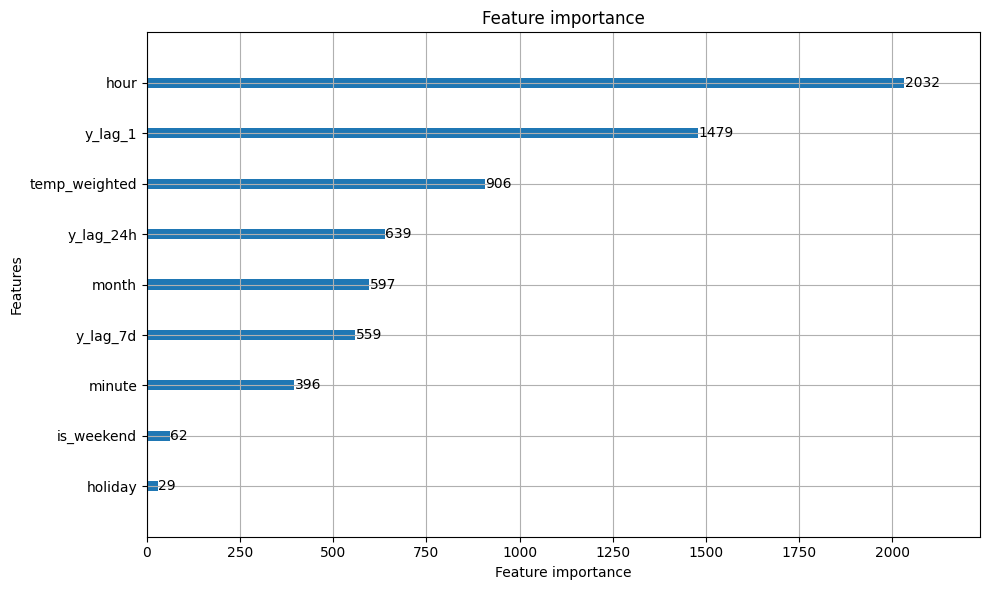

In [11]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt

lgb.plot_importance(final_model, max_num_features=15, figsize=(10, 6))
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

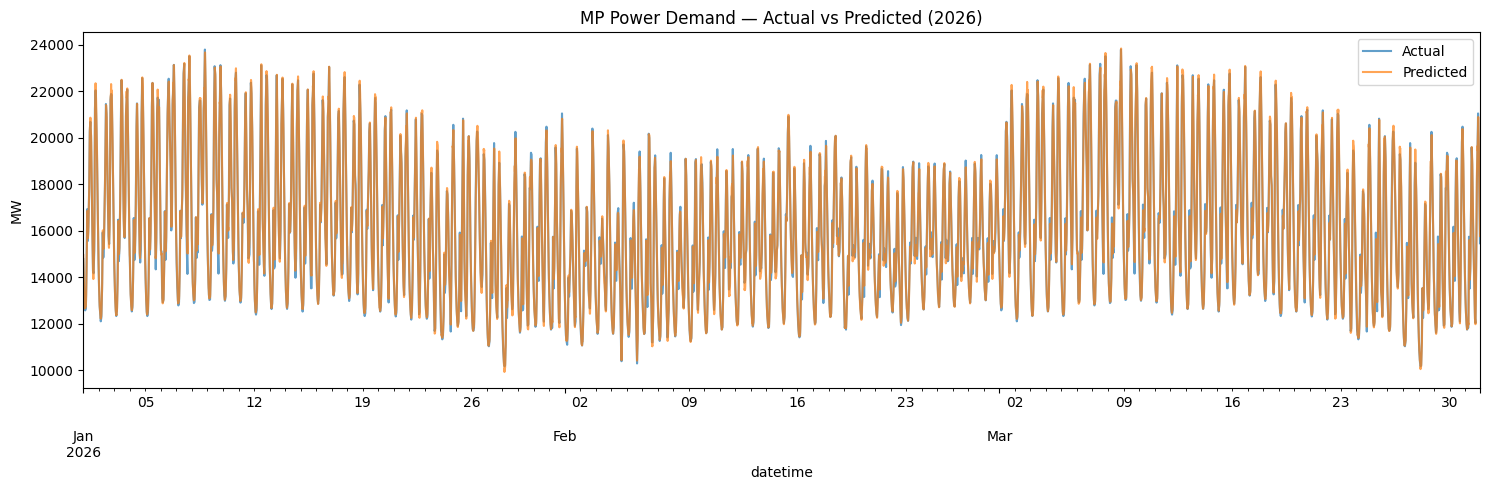

In [12]:
results = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_pred
}, index=X_test.index)

plt.figure(figsize=(15, 5))
results['actual'].plot(label='Actual', alpha=0.7)
results['predicted'].plot(label='Predicted', alpha=0.7)
plt.title('MP Power Demand — Actual vs Predicted (2026)')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

In [13]:
final_model.save_model('mp_lgbm_final.txt')

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Train
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_model.fit(X_train, y_train)

# Evaluate on val
y_val_pred = rf_model.predict(X_val)
val_mape   = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
print(f'Val MAPE: {val_mape:.2f}%')

# Evaluate on test
y_pred_rf = rf_model.predict(X_test)
mae    = np.mean(np.abs(y_test - y_pred_rf))
rmse   = np.sqrt(np.mean((y_test - y_pred_rf) ** 2))
mape   = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2     = r2_score(y_test, y_pred_rf)
max_err = np.max(np.abs(y_test - y_pred_rf))

print(f'MAE      : {mae:.2f} MW')
print(f'RMSE     : {rmse:.2f} MW')
print(f'MAPE     : {mape:.2f}%')
print(f'R2       : {r2:.4f}')
print(f'Max Error: {max_err:.2f} MW')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    4.6s


Val MAPE: 0.93%
MAE      : 235.32 MW
RMSE     : 313.89 MW
MAPE     : 1.44%
R2       : 0.9885
Max Error: 1548.83 MW


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    5.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


In [15]:
import optuna
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 10, 40),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_float('max_features', 0.5, 1.0),
        'n_jobs':           -1,
        'random_state':     42
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    mape = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
    return mape

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective, n_trials=30)  # 30 not 50 — RF is slower per trial

print('Best params:', study_rf.best_params)
print('Best val MAPE:', study_rf.best_value)

# Retrain with best params
best_rf = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42)
best_rf.fit(X_trainval, y_trainval)  # train on train+val combined

y_pred_rf = best_rf.predict(X_test)
mape  = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
rmse  = np.sqrt(np.mean((y_test - y_pred_rf) ** 2))
mae   = np.mean(np.abs(y_test - y_pred_rf))
r2    = r2_score(y_test, y_pred_rf)

print(f'Final Test MAPE: {mape:.2f}%')
print(f'Final Test RMSE: {rmse:.2f} MW')
print(f'Final Test MAE:  {mae:.2f} MW')
print(f'Final Test R2:   {r2:.4f}')

[I 2026-06-16 15:05:55,925] A new study created in memory with name: no-name-5f6c16a4-5d68-4e28-b062-6eb208946a79
[I 2026-06-16 15:05:58,982] Trial 0 finished with value: 0.9954223865901085 and parameters: {'n_estimators': 153, 'max_depth': 11, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 0.7120197158538334}. Best is trial 0 with value: 0.9954223865901085.
[I 2026-06-16 15:06:05,643] Trial 1 finished with value: 0.993141759116151 and parameters: {'n_estimators': 382, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 0.5462418922756522}. Best is trial 1 with value: 0.993141759116151.
[I 2026-06-16 15:06:11,625] Trial 2 finished with value: 1.1141363876744272 and parameters: {'n_estimators': 402, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 0.6006435052670085}. Best is trial 1 with value: 0.993141759116151.
[I 2026-06-16 15:06:19,921] Trial 3 finished with value: 0.951139636999789 and parameters: {'n_es

Best params: {'n_estimators': 494, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 0.8805397253459636}
Best val MAPE: 0.9243010962197555
Final Test MAPE: 1.36%
Final Test RMSE: 299.31 MW
Final Test MAE:  222.62 MW
Final Test R2:   0.9896


In [16]:
# Simple average ensemble
y_pred_ensemble = (y_pred * 0.5) + (y_pred_rf * 0.5)

mae   = np.mean(np.abs(y_test - y_pred_ensemble))
rmse  = np.sqrt(np.mean((y_test - y_pred_ensemble) ** 2))
mape  = np.mean(np.abs((y_test - y_pred_ensemble) / y_test)) * 100
r2    = r2_score(y_test, y_pred_ensemble)

print(f'Ensemble MAPE: {mape:.3f}%')
print(f'Ensemble RMSE: {rmse:.2f} MW')
print(f'Ensemble MAE:  {mae:.2f} MW')
print(f'Ensemble R2:   {r2:.4f}')

Ensemble MAPE: 1.284%
Ensemble RMSE: 282.89 MW
Ensemble MAE:  210.10 MW
Ensemble R2:   0.9907


In [17]:
# Try different weights
for lgbm_w in [0.4, 0.5, 0.6, 0.7]:
    rf_w = 1 - lgbm_w
    y_blend = (y_pred * lgbm_w) + (y_pred_rf * rf_w)
    mape = np.mean(np.abs((y_test - y_blend) / y_test)) * 100
    rmse = np.sqrt(np.mean((y_test - y_blend) ** 2))
    print(f'LGBM {lgbm_w:.0%} / RF {rf_w:.0%} → MAPE: {mape:.3f}%, RMSE: {rmse:.2f}')

LGBM 40% / RF 60% → MAPE: 1.296%, RMSE: 285.56
LGBM 50% / RF 50% → MAPE: 1.284%, RMSE: 282.89
LGBM 60% / RF 40% → MAPE: 1.274%, RMSE: 280.55
LGBM 70% / RF 30% → MAPE: 1.266%, RMSE: 278.55


In [18]:
y_pred_final = (y_pred * 0.6) + (y_pred_rf * 0.4)

mae   = np.mean(np.abs(y_test - y_pred_final))
rmse  = np.sqrt(np.mean((y_test - y_pred_final) ** 2))
mape  = np.mean(np.abs((y_test - y_pred_final) / y_test)) * 100
r2    = r2_score(y_test, y_pred_final)
max_err = np.max(np.abs(y_test - y_pred_final))
median_ae = np.median(np.abs(y_test - y_pred_final))

print(f'Final Ensemble MAPE     : {mape:.3f}%')
print(f'Final Ensemble RMSE     : {rmse:.2f} MW')
print(f'Final Ensemble MAE      : {mae:.2f} MW')
print(f'Final Ensemble R2       : {r2:.4f}')
print(f'Final Ensemble Max Error: {max_err:.2f} MW')
print(f'Final Ensemble Median AE: {median_ae:.2f} MW')

Final Ensemble MAPE     : 1.274%
Final Ensemble RMSE     : 280.55 MW
Final Ensemble MAE      : 208.38 MW
Final Ensemble R2       : 0.9908
Final Ensemble Max Error: 1362.57 MW
Final Ensemble Median AE: 151.65 MW


In [19]:
"""
Best params: {'n_estimators': 258, 'max_depth': 38, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.9294392572105932}
Best val MAPE: 0.7089540681136403
Final Test MAPE: 0.95%
Final Test RMSE: 181.35 MW
Final Test MAE:  130.00 MW
Final Test R2:   0.9962



FOR RF
"""

"\nBest params: {'n_estimators': 258, 'max_depth': 38, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.9294392572105932}\nBest val MAPE: 0.7089540681136403\nFinal Test MAPE: 0.95%\nFinal Test RMSE: 181.35 MW\nFinal Test MAE:  130.00 MW\nFinal Test R2:   0.9962\n\n\n\nFOR RF\n"

In [20]:
"""
Best params: {'learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443}
MAE        : 128.21 MW        — average absolute error
RMSE       : 184.27 MW        — penalizes large errors more
MSE        : 33957.11            — squared error
MAPE       : 0.91%          — % error relative to actual
SMAPE      : 0.91%         — symmetric MAPE
R2 Score   : 0.9960            — 1.0 is perfect
Max Error  : 1475.80 MW     — worst single prediction
Median AE  : 92.82 MW   — error at 50th percentile


lightgbm
"""
#better 



"\nBest params: {'learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443}\nMAE        : 128.21 MW        — average absolute error\nRMSE       : 184.27 MW        — penalizes large errors more\nMSE        : 33957.11            — squared error\nMAPE       : 0.91%          — % error relative to actual\nSMAPE      : 0.91%         — symmetric MAPE\nR2 Score   : 0.9960            — 1.0 is perfect\nMax Error  : 1475.80 MW     — worst single prediction\nMedian AE  : 92.82 MW   — error at 50th percentile\n\n\nlightgbm\n"

In [21]:
# best param 
# LGBM 60% / RF 40% → MAPE: 0.890%, RMSE: 172.23

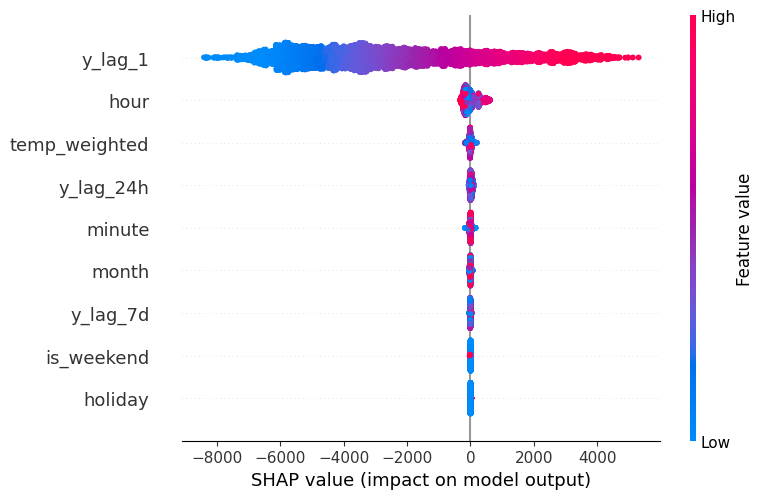

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


IndexError: tuple index out of range

In [24]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — feature importance by impact
shap.summary_plot(shap_values, X_test)

# Single prediction explanation
shap.waterfall_plot(explainer(X_test.iloc[0]))

In [25]:
import pickle

with open("lightgbm_model.pkl", "wb") as f:
    pickle.dump(final_model, f)